# 10. キャップストーン — 1 つの熱拡散を、3 つのレンズで見る

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture / 2. Problem |
| Applied | 3. PDE レンズ 〜 5. Fourier レンズ |
| Advanced | 6. 統合 / 7. Advanced Notes |

## 1. Big Picture

本シリーズ(微分積分 → ODE → PDE)で学んだ道具は、実は **同じ一つの考え** の別の顔でした。
それを、**両端を冷やした棒の温度がどう均されるか** という一つの現象を **3 通り** に解いて確かめます。

- **PDE レンズ**: 連続の場として $\partial_t u = \alpha\,\partial_{xx} u$ を解く(本書の中心)。
- **ODE レンズ**: 空間を格子で刻み、各格子点の温度を成分とする **連立 ODE** $d\mathbf{u}/dt = \alpha L\mathbf{u}$ に直す(ODE 書 03 章の $d\mathbf{x}/dt=A\mathbf{x}$)。
- **Fourier レンズ**: 初期条件をサイン波に分解し、各モードを独立に $e^{-\alpha k^2 t}$ で減衰させて足す(04/05 章)。

3 つが **同じ答え** を返すこと、そしてなぜ一致するのか(サイン波 = ラプラシアンの固有ベクトル)を見ます。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import solvers, plotting
from scipy.integrate import solve_ivp
import numpy as np

# One setup shared by all three lenses: a bar [0,1], cold ends, a bump in the middle.
n = 101
x = np.linspace(0, 1, n)
dx = x[1] - x[0]
alpha = 1.0
u_init = np.exp(-((x - 0.5) ** 2) / 0.01)
u_init[0] = u_init[-1] = 0.0          # Dirichlet: ends held at 0
t_end = 0.02

## 2. Problem

初期温度 $u(x,0)$ は中央が熱い山。両端は $0$ に固定。時刻 $t=0.02$ での温度分布を求めよ——
を、3 つのレンズで独立に解き、突き合わせます。

## 3. PDE レンズ — 連続の場として解く

有限差分法(05 章)でそのまま時間発展させます。

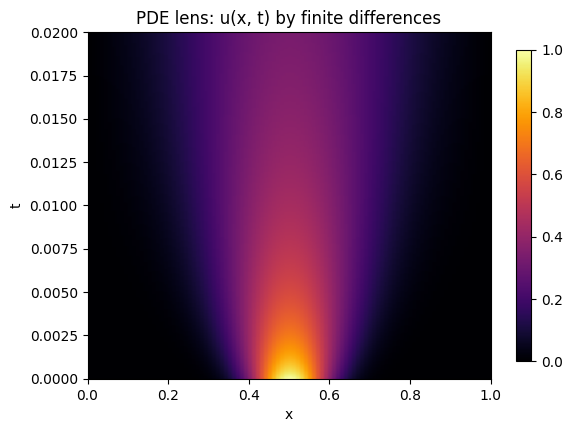

In [3]:
# Lens 1: the PDE itself, via finite differences.
dt = 0.4 * dx**2 / alpha
steps = int(round(t_end / dt))
U_pde = solvers.solve_heat_explicit(u_init, alpha, dx, dt, steps)
u_pde = U_pde[-1]
plotting.space_time_heatmap(U_pde, x, np.arange(steps + 1) * dt,
                            title="PDE lens: u(x, t) by finite differences")
plt.show()

## 4. ODE レンズ — 連立 ODE(線法 method of lines)

空間微分だけを差分化し、時間は連続のまま残すと、各格子点の温度 $u_i(t)$ についての **連立常微分方程式**

$$
\frac{d\mathbf{u}}{dt} = \alpha L\mathbf{u}, \qquad
L = \frac{1}{\Delta x^2}\,\mathrm{tridiag}(1, -2, 1)
$$

になります。これは ODE 書 03 章の $d\mathbf{x}/dt = A\mathbf{x}$ そのもの。`solve_ivp` で積分し、
さらに $\alpha L$ の **固有値**(= 各モードの減衰率)を見ます。

In [4]:
# Lens 2: method of lines -> a coupled linear ODE system du/dt = alpha L u.
m = n - 2  # interior nodes (ends fixed at 0)
L = (np.diag(-2 * np.ones(m)) + np.diag(np.ones(m - 1), 1) + np.diag(np.ones(m - 1), -1)) / dx**2
A = alpha * L

sol = solve_ivp(lambda t, u: A @ u, (0, t_end), u_init[1:-1], t_eval=[t_end], rtol=1e-9, atol=1e-12)
u_ode = np.concatenate([[0.0], sol.y[:, -1], [0.0]])

evals = np.sort(np.linalg.eigvalsh(A))[::-1]  # decay rates (most negative = fastest)
print("slowest 3 decay rates (eig of alpha L):", np.round(evals[:3], 2))
print("compare -alpha (n pi)^2 for n=1,2,3 :", np.round([-alpha * (k * np.pi) ** 2 for k in (1, 2, 3)], 2))

slowest 3 decay rates (eig of alpha L): [ -9.87 -39.47 -88.76]
compare -alpha (n pi)^2 for n=1,2,3 : [ -9.87 -39.48 -88.83]


$\alpha L$ の固有値が $-\alpha(n\pi)^2$ にほぼ一致します。つまり **連立 ODE の各「固有モード」は、
ちょうどサイン波**。ここで Fourier レンズに自然につながります。

## 5. Fourier レンズ — モードに分解して独立に減衰

初期条件をサイン波 $\sin(n\pi x)$ に分解し($b_n=2\int_0^1 u_0\sin(n\pi x)\,dx$)、各モードを
$e^{-\alpha(n\pi)^2 t}$ で減衰させて足し戻します(05 章の変数分離)。

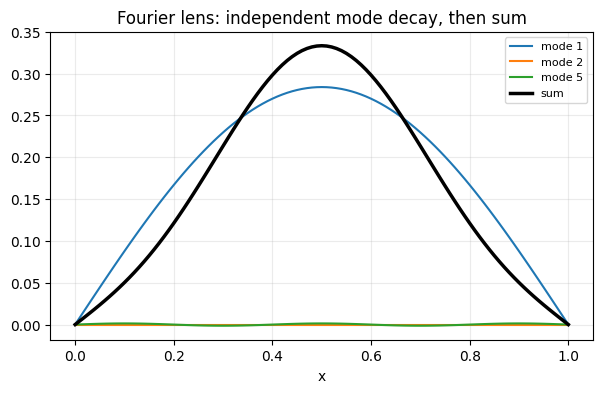

In [5]:
# Lens 3: expand in sine modes, decay each independently, sum.
N_modes = 60
b = np.array([2 * np.trapezoid(u_init * np.sin(k * np.pi * x), x) for k in range(1, N_modes + 1)])
u_fourier = sum(
    b[k - 1] * np.exp(-alpha * (k * np.pi) ** 2 * t_end) * np.sin(k * np.pi * x)
    for k in range(1, N_modes + 1)
)

fig, ax = plt.subplots(figsize=(7, 4))
for k in (1, 2, 5):
    ax.plot(x, b[k - 1] * np.exp(-alpha * (k * np.pi) ** 2 * t_end) * np.sin(k * np.pi * x),
            lw=1.5, label=f"mode {k}")
ax.plot(x, u_fourier, "k", lw=2.5, label="sum")
ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.set_xlabel("x")
ax.set_title("Fourier lens: independent mode decay, then sum")
plt.show()

## 6. 統合 — 3 つは同じ答え

3 つのレンズの $t=0.02$ での解を重ねます。**ほぼ完全に一致** します。

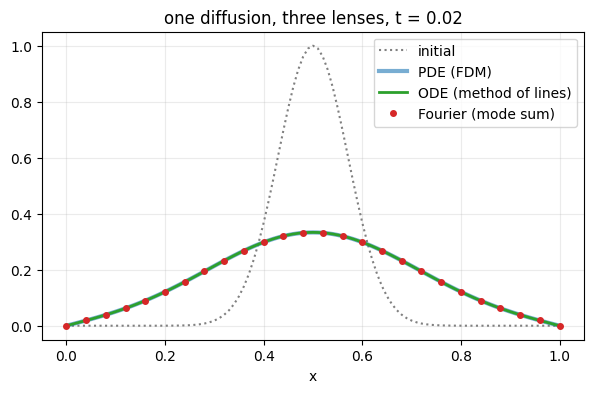

max |PDE - ODE|     = 0.00019692431078499606
max |PDE - Fourier| = 0.00011483090516073435


In [6]:
# All three agree.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, u_init, color="gray", ls=":", label="initial")
ax.plot(x, u_pde, color="#1f77b4", lw=3, alpha=0.6, label="PDE (FDM)")
ax.plot(x, u_ode, color="#2ca02c", lw=2, label="ODE (method of lines)")
ax.plot(x[::4], u_fourier[::4], "o", ms=4, color="#d62728", label="Fourier (mode sum)")
ax.legend(); ax.grid(alpha=0.25); ax.set_xlabel("x")
ax.set_title("one diffusion, three lenses, t = 0.02")
plt.show()
print("max |PDE - ODE|     =", float(np.max(np.abs(u_pde - u_ode))))
print("max |PDE - Fourier| =", float(np.max(np.abs(u_pde - u_fourier))))

### なぜ一致するのか — 一本の糸

サイン波 $\sin(n\pi x)$ は **ラプラシアン $\partial_{xx}$(およびその離散版 $L$)の固有ベクトル** で、固有値は $-(n\pi)^2$。

- **線形代数**: $L$ を固有基底で見ると対角行列になる(対角化)。
- **ODE**: 対角化された系は、各成分が独立な $\dot{c}_n = -\alpha(n\pi)^2 c_n$ という **スカラー ODE** に分解される。
- **Fourier / 変数分離**: その「固有基底に分解する」操作こそが Fourier 展開であり、各モードの独立減衰が解。
- **PDE**: 連続極限でも全く同じ構造。

> **微分方程式・線形代数・Fourier は、「固有モードに分解して、各モードを独立に進める」という
> 一つの考えの異なる顔である。** これが本シリーズを貫く一本の糸です。

## 関連教材

- [`../../linear_algebra`](../../linear_algebra/) — 固有値・対角化(この一致の根拠)
- [`../ode-book`](../ode-book/) — 03 章 $d\mathbf{x}/dt=A\mathbf{x}$ / 04 章 固有値による分類
- 本書 04 章(Fourier)・05 章(変数分離)

## Exercises

1. 初期条件を非対称(例: 段差)に変えても 3 レンズが一致することを確かめよ。
2. Fourier レンズの項数 `N_modes` を減らすと、どこで誤差が現れるか(不連続点 vs 滑らかな部分)を調べよ。
3. ODE レンズの $\alpha L$ の固有ベクトルを実際に描き、$\sin(n\pi x)$ に一致することを示せ。

## Advanced Notes

- **method of lines (線法)**: 空間だけ離散化して大きな ODE 系にし、成熟した ODE ソルバ(剛性対応の `solve_ivp(method="BDF")` など)に任せる実務的手法。$L$ は剛性が高い(固有値が $-(N\pi)^2$ まで広がる)。
- **スペクトル精度**: Fourier レンズはモードを増やすほど指数的に精度が上がる(滑らかな解なら)。これが 09 章スペクトル法の威力。
- **非線形では崩れる**: 重ね合わせ(Fourier 分解の独立性)は **線形** だから成り立つ。Burgers/KdV(09 章)など非線形ではモードが結合し、この素直な分解は使えない。